# Pair Classifier — 3-class: Confident Match / Confident Non-match / Ambiguous (LightGBM, **v1**)

**A new model type.** The earlier notebooks were binary (match vs non-match, or — over *plausible*
pairs — match vs ambiguous). This one is **multiclass over the whole gold-label dataset** and
predicts one of three outcomes for a record pair:

| class | code | definition |
|---|---|---|
| **confident non-match** | 0 | `ambiguous_pair = False` **and** `final_gold_label = False` |
| **confident match** | 1 | `ambiguous_pair = False` **and** `final_gold_label = True` |
| **ambiguous** | 2 | `ambiguous_pair = True` (route to human review) |

These three classes **partition every pair** — no population filter, unlike the plausible-pairs
model. Features are **identical to the match-vs-ambiguous v3 model** (same Jaro-Winkler / Levenshtein
similarities, `sim_dob`, `sim_phones`, phonetic `sound_*`, street number, etc.); only the target and
the multiclass head change.

**Structure:** 1) setup · 2) ingestion · 3) 3-class target · 4) field selection · 5) feature
engineering (= v3) · 6) split · 7) training · 8) evaluation · 9) v1-vs-full ablation.

> Standalone training/evaluation notebook — not wired into `src/pipeline.py`.

## 1. Setup & configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import jellyfish

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)

pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

In [3]:
from pathlib import Path

def _find_service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / 'data').is_dir() and (d / 'src').is_dir():
            return d
    raise FileNotFoundError("could not locate empi-service/ (no ancestor has data/ + src/)")

SERVICE_ROOT = _find_service_root(Path.cwd())
DATA_DIR = SERVICE_ROOT / 'data'

GOLD_LABELS_PATH = DATA_DIR / 'gold_labels' / 'final_gold_labels_v1_2026_07_05.csv'
CLEANED_PATH = DATA_DIR / 'processed' / 'MDM_Population_cleaned_v6_2026_06_25.parquet'

print('service root :', SERVICE_ROOT)
print('gold labels  :', GOLD_LABELS_PATH, '-> exists:', GOLD_LABELS_PATH.exists())
print('cleaned data :', CLEANED_PATH, '-> exists:', CLEANED_PATH.exists())

service root : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
gold labels  : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\gold_labels\final_gold_labels_v1_2026_07_05.csv -> exists: True
cleaned data : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\processed\MDM_Population_cleaned_v6_2026_06_25.parquet -> exists: True


## 2. Data ingestion
Same as the v3 model. `dtype=str` on PATIDs preserves the leading-zeros invariant.

In [4]:
gold = pd.read_csv(GOLD_LABELS_PATH, dtype={'PATID_A': str, 'PATID_B': str})


def _to_bool(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    return s.astype(str).str.strip().str.lower().map(
        {'true': True, '1': True, '1.0': True, 'false': False, '0': False, '0.0': False})


gold['final_gold_label'] = _to_bool(gold['final_gold_label']).fillna(False).astype(bool)
gold['ambiguous_pair'] = _to_bool(gold['ambiguous_pair']).fillna(False).astype(bool)

print('gold labels shape :', gold.shape)
print('\nfinal_gold_label x ambiguous_pair (counts):')
print(pd.crosstab(gold['final_gold_label'], gold['ambiguous_pair']))

gold labels shape : (204805, 4)

final_gold_label x ambiguous_pair (counts):
ambiguous_pair     False  True 
final_gold_label               
False             142195     73
True               34560  27977


In [5]:
ATTRIBUTE_COLS = [
    'FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean',
    'SSN_clean', 'last_4_SSN', 'Email_clean', 'ZipCD_clean_base',
    'AddressLine1_clean', 'SexAtBirthDSC_clean', 'Phones_set',
]
cleaned = pd.read_parquet(CLEANED_PATH)
keep = ['PATID'] + [c for c in ATTRIBUTE_COLS if c in cleaned.columns]
cleaned = cleaned[keep].copy()
cleaned['PATID'] = cleaned['PATID'].astype(str)
cleaned = cleaned.drop_duplicates(subset='PATID', keep='first').set_index('PATID')
print('cleaned records shape:', cleaned.shape)
print('columns available    :', list(cleaned.columns))

cleaned records shape: (163364, 11)
columns available    : ['FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean', 'SSN_clean', 'last_4_SSN', 'Email_clean', 'ZipCD_clean_base', 'AddressLine1_clean', 'SexAtBirthDSC_clean', 'Phones_set']


In [6]:
a = cleaned.add_suffix('_A').reindex(gold['PATID_A'].values).reset_index(drop=True)
b = cleaned.add_suffix('_B').reindex(gold['PATID_B'].values).reset_index(drop=True)
pairs = pd.concat([gold.reset_index(drop=True), a, b], axis=1)

n_unmatched = (~gold['PATID_A'].isin(cleaned.index) | ~gold['PATID_B'].isin(cleaned.index)).sum()
print(f'pairs with a PATID not found in cleaned data: {n_unmatched} / {len(pairs)}')
print('joined pairs shape:', pairs.shape)

pairs with a PATID not found in cleaned data: 0 / 204805
joined pairs shape: (204805, 26)


## 3. Three-class target — whole dataset (no population filter)

Every pair maps to exactly one class. `ambiguous_pair` takes precedence: an ambiguous pair is
class 2 regardless of `final_gold_label` (this folds in the handful of `final=False & ambiguous=True`
pairs, which are ambiguous by definition).

In [7]:
CLASS_NAMES = ['confident_non_match', 'confident_match', 'ambiguous']   # index == class code 0/1/2

amb = pairs['ambiguous_pair']
match = pairs['final_gold_label']
pairs['target_class'] = np.select(
    [(~amb) & (~match), (~amb) & match, amb],
    [0, 1, 2],
    default=-1,
)
assert (pairs['target_class'] >= 0).all(), 'every pair must fall into exactly one class'

counts = pairs['target_class'].value_counts().sort_index()
print('class distribution:')
for k, name in enumerate(CLASS_NAMES):
    print(f'  {k} {name:20s}: {counts.get(k, 0):7d}  ({counts.get(k, 0)/len(pairs):.1%})')

class distribution:
  0 confident_non_match :  142195  (69.4%)
  1 confident_match     :   34560  (16.9%)
  2 ambiguous           :   28050  (13.7%)


## 4. Field selection
Same 8-field roster as v3.

In [8]:
AVAILABLE_FIELDS = {
    'first_name':  'FirstNM_clean',
    'last_name':   'LastNM_clean',
    'middle_name': 'MiddleNM_clean',
    'birth_date':  'BirthDT_clean',
    'email':       'Email_clean',
    'ssn':         'SSN_clean',
    'address1':    'AddressLine1_clean',
    'phones':      'Phones_set',
}
SET_FIELDS = {'phones'}
SELECTED_FIELDS = ['first_name', 'last_name', 'middle_name', 'birth_date',
                   'email', 'ssn', 'address1', 'phones']
assert set(SELECTED_FIELDS) <= set(AVAILABLE_FIELDS)
print('fields:', SELECTED_FIELDS)

fields: ['first_name', 'last_name', 'middle_name', 'birth_date', 'email', 'ssn', 'address1', 'phones']


## 5. Feature engineering (identical to the v3 model)

All continuous **except** `cmp_street_num`, `sound_first`, `sound_last`. Missing on either side →
`NaN`, handled natively by LightGBM.

| Feature | Type | Definition |
|---|---|---|
| `sim_jw_first` / `sim_jw_last` / `sim_jw_middle` | num | Jaro-Winkler on the name |
| `sound_first` / `sound_last` | cat | Metaphone code match (sound-alike) |
| `sim_lev_email` | num | normalized Levenshtein on email |
| `sim_lev_address1` | num | normalized Levenshtein on address line 1 |
| `addr_token_jaccard` | num | token overlap (Jaccard) of the address |
| `cmp_street_num` | cat | first numeric token of the address, matched exactly |
| `ssn_digit_frac` | num | fraction of position-wise matching SSN digits |
| `sim_dob` | num | normalized Levenshtein on the `YYYYMMDD` birth-date string |
| `sim_phones` | num | best (max) Jaro-Winkler across all cross pairs of the two phone sets |

In [9]:
import ast, re

MISSING, SAME, DIFFERENT = 'missing', 'same', 'different'
COMPARE_LEVELS = [MISSING, SAME, DIFFERENT]
_num_re = re.compile(r'\d+')
_NA_TOKENS = {'nan', 'none', '<na>', 'nat', 'null'}


def _norm(x):
    """Value -> lowercased stripped str, or None for any missing kind (None/np.nan/pd.NA/NaT)."""
    if isinstance(x, str):
        s = x.strip().lower()
        return s if s and s not in _NA_TOKENS else None
    if x is None:
        return None
    try:
        if pd.isna(x):
            return None
    except (TypeError, ValueError):
        pass
    s = str(x).strip().lower()
    return s if s and s not in _NA_TOKENS else None


def _norm_series(s: pd.Series) -> pd.Series:
    return s.astype(object).map(_norm)


def _parse_set(value) -> set:
    if isinstance(value, (set, frozenset, list, tuple, np.ndarray)):
        return {str(p).strip() for p in value if str(p).strip()}
    if pd.isna(value) or not isinstance(value, str):
        return set()
    v = value.strip()
    if v in ('', 'nan', 'None', 'set()', '{}', '[]'):
        return set()
    try:
        parsed = ast.literal_eval(v)
        if isinstance(parsed, (set, list, tuple)):
            return {str(p).strip() for p in parsed if str(p).strip()}
    except (ValueError, SyntaxError, TypeError):
        pass
    cleaned = v.strip('{}[]').replace("'", '').replace('"', '')
    return {p.strip() for p in cleaned.split(',') if p.strip()}


def _jw(x, y):
    if not (isinstance(x, str) and isinstance(y, str)):
        return np.nan
    return jellyfish.jaro_winkler_similarity(x, y)


def _lev_sim(x, y):
    if not (isinstance(x, str) and isinstance(y, str)):
        return np.nan
    m = max(len(x), len(y))
    return 1.0 - jellyfish.levenshtein_distance(x, y) / m if m else np.nan

### 5.1 Internal per-field comparison (`cmp_all`)
Not a model feature — used only for the section-9 ablation baseline (the eight v1 categoricals).

In [10]:
def compare_field(df: pd.DataFrame, name: str, col: str) -> pd.Categorical:
    if name in SET_FIELDS:
        a = df[f'{col}_A'].apply(_parse_set)
        b = df[f'{col}_B'].apply(_parse_set)
        missing = (a.map(len) == 0) | (b.map(len) == 0)
        same = pd.Series([bool(x & y) for x, y in zip(a, b)], index=df.index) & ~missing
    else:
        a = _norm_series(df[f'{col}_A'])
        b = _norm_series(df[f'{col}_B'])
        missing = a.isna() | b.isna()
        same = (a == b) & ~missing
    out = np.where(missing, MISSING, np.where(same, SAME, DIFFERENT))
    return pd.Categorical(out, categories=COMPARE_LEVELS)


cmp_all = pd.DataFrame(index=pairs.index)
for name in SELECTED_FIELDS:
    cmp_all[f'cmp_{name}'] = compare_field(pairs, name, AVAILABLE_FIELDS[name])
print('internal cmp_all columns:', list(cmp_all.columns))

internal cmp_all columns: ['cmp_first_name', 'cmp_last_name', 'cmp_middle_name', 'cmp_birth_date', 'cmp_email', 'cmp_ssn', 'cmp_address1', 'cmp_phones']


### 5.2 Model features

In [11]:
feat = pd.DataFrame(index=pairs.index)
cat_features, num_features = [], []


def sim_column(col, fn):
    a = _norm_series(pairs[f'{col}_A'])
    b = _norm_series(pairs[f'{col}_B'])
    return pd.Series([fn(x, y) for x, y in zip(a, b)], index=pairs.index, dtype='float')


# --- Names: Jaro-Winkler ---
for name in ['first_name', 'last_name', 'middle_name']:
    feat[f'sim_jw_{name.split("_")[0]}'] = sim_column(AVAILABLE_FIELDS[name], _jw)
num_features += ['sim_jw_first', 'sim_jw_last', 'sim_jw_middle']

# --- Email / address: normalized Levenshtein ---
feat['sim_lev_email'] = sim_column('Email_clean', _lev_sim)
feat['sim_lev_address1'] = sim_column('AddressLine1_clean', _lev_sim)
num_features += ['sim_lev_email', 'sim_lev_address1']

In [12]:
# --- Names: phonetic (Metaphone) sound-alike match ---
def _metaphone(x):
    s = _norm(x)
    if not s:
        return None
    return jellyfish.metaphone(s) or None


def sound_cmp(col):
    a = pairs[f'{col}_A'].map(_metaphone)
    b = pairs[f'{col}_B'].map(_metaphone)
    missing = a.isna() | b.isna()
    same = (a == b) & ~missing
    return pd.Categorical(np.where(missing, MISSING, np.where(same, SAME, DIFFERENT)), categories=COMPARE_LEVELS)


feat['sound_first'] = sound_cmp('FirstNM_clean')
feat['sound_last'] = sound_cmp('LastNM_clean')
cat_features += ['sound_first', 'sound_last']

In [13]:
# --- Address: street number (first numeric token) matched exactly; + token Jaccard ---
def _street_num(x):
    s = _norm(x)
    if not s:
        return None
    m = _num_re.search(s)
    return m.group() if m else None


sn_a = pairs['AddressLine1_clean_A'].map(_street_num)
sn_b = pairs['AddressLine1_clean_B'].map(_street_num)
sn_missing = sn_a.isna() | sn_b.isna()
sn_same = (sn_a == sn_b) & ~sn_missing
feat['cmp_street_num'] = pd.Categorical(
    np.where(sn_missing, MISSING, np.where(sn_same, SAME, DIFFERENT)), categories=COMPARE_LEVELS)
cat_features.append('cmp_street_num')


def _tok_jaccard(x, y):
    x, y = _norm(x), _norm(y)
    if not x or not y:
        return np.nan
    sx, sy = set(x.split()), set(y.split())
    return len(sx & sy) / len(sx | sy) if sx and sy else np.nan


feat['addr_token_jaccard'] = pd.Series(
    [_tok_jaccard(x, y) for x, y in zip(pairs['AddressLine1_clean_A'], pairs['AddressLine1_clean_B'])],
    index=pairs.index, dtype='float')
num_features.append('addr_token_jaccard')

In [14]:
# --- SSN: fraction of position-wise matching digits ---
def _ssn_frac(x, y):
    x, y = _norm(x), _norm(y)
    if not x or not y:
        return np.nan
    n = min(len(x), len(y))
    if n == 0:
        return np.nan
    return sum(1 for i in range(n) if x[i] == y[i]) / max(len(x), len(y))


feat['ssn_digit_frac'] = pd.Series(
    [_ssn_frac(x, y) for x, y in zip(pairs['SSN_clean_A'], pairs['SSN_clean_B'])],
    index=pairs.index, dtype='float')
num_features.append('ssn_digit_frac')

In [15]:
# --- DOB: typo-tolerant similarity on the YYYYMMDD digit string ---
dob_a = pd.to_datetime(pairs['BirthDT_clean_A'], errors='coerce')
dob_b = pd.to_datetime(pairs['BirthDT_clean_B'], errors='coerce')
sa = dob_a.dt.strftime('%Y%m%d')
sb = dob_b.dt.strftime('%Y%m%d')
feat['sim_dob'] = pd.Series([_lev_sim(x, y) for x, y in zip(sa, sb)], index=pairs.index, dtype='float')
num_features.append('sim_dob')

In [16]:
# --- Phones: best (max) Jaro-Winkler across all cross pairs of the two phone sets ---
def _phones_best_jw(av, bv):
    A, B = _parse_set(av), _parse_set(bv)
    if not A or not B:
        return np.nan
    return max(jellyfish.jaro_winkler_similarity(x, y) for x in A for y in B)


feat['sim_phones'] = pd.Series(
    [_phones_best_jw(av, bv) for av, bv in zip(pairs['Phones_set_A'], pairs['Phones_set_B'])],
    index=pairs.index, dtype='float')
num_features.append('sim_phones')

In [17]:
for c in cat_features:
    feat[c] = feat[c].astype('category')

FEATURE_COLS = cat_features + num_features
print(f'{len(cat_features)} categorical + {len(num_features)} numeric = {len(FEATURE_COLS)} features')
print('\ncategorical:', cat_features)
print('numeric    :', num_features)
feat[FEATURE_COLS].head()

3 categorical + 9 numeric = 12 features

categorical: ['sound_first', 'sound_last', 'cmp_street_num']
numeric    : ['sim_jw_first', 'sim_jw_last', 'sim_jw_middle', 'sim_lev_email', 'sim_lev_address1', 'addr_token_jaccard', 'ssn_digit_frac', 'sim_dob', 'sim_phones']


,sound_first,sound_last,cmp_street_num,sim_jw_first,sim_jw_last,sim_jw_middle,sim_lev_email,sim_lev_address1,addr_token_jaccard,ssn_digit_frac,sim_dob,sim_phones
0,same,same,same,1.000000,1.0,NaN,NaN,1.000000,1.000000,NaN,1.0,1.000000
1,same,same,same,1.000000,1.0,NaN,0.464286,1.000000,1.000000,NaN,1.0,1.000000
2,same,same,same,0.971429,1.0,NaN,NaN,1.000000,1.000000,NaN,1.0,1.000000
3,same,same,different,1.000000,1.0,NaN,1.000000,0.285714,0.166667,1.0,1.0,1.000000
4,same,same,different,1.000000,1.0,NaN,NaN,0.476190,0.333333,NaN,1.0,0.622222


### 5.3 Feature ↔ class signal check

In [18]:
print('Numeric features — mean by class:')
means = feat[num_features].groupby(pairs['target_class']).mean().T
means.columns = [CLASS_NAMES[c] for c in means.columns]
display(means.round(3))

for c in cat_features:
    print(f'\n{c} — class share within each outcome:')
    ct = pd.crosstab(feat[c].astype('object'), pairs['target_class'], normalize='index')
    ct.columns = [CLASS_NAMES[k] for k in ct.columns]
    print(ct.round(3))

Numeric features — mean by class:


,confident_non_match,confident_match,ambiguous
sim_jw_first,0.445,0.989,0.997
sim_jw_last,0.477,0.975,0.957
sim_jw_middle,0.143,0.916,0.841
sim_lev_email,0.613,0.872,0.610
sim_lev_address1,0.690,0.638,0.341
addr_token_jaccard,0.600,0.519,0.160
ssn_digit_frac,0.199,0.990,0.740
sim_dob,0.468,1.000,1.000
sim_phones,0.962,0.865,0.724



sound_first — class share within each outcome:
             confident_non_match  confident_match  ambiguous
sound_first                                                 
different                  0.989            0.010      0.002
missing                    0.000            0.000      1.000
same                       0.070            0.506      0.424

sound_last — class share within each outcome:
            confident_non_match  confident_match  ambiguous
sound_last                                                 
different                 0.935            0.025      0.040
missing                   0.000            1.000      0.000
same                      0.231            0.446      0.324

cmp_street_num — class share within each outcome:
                confident_non_match  confident_match  ambiguous
cmp_street_num                                                 
different                     0.584            0.162      0.254
missing                       0.413            0.152     

## 6. Train / validation / test split
Random split stratified on the 3-class target (60/20/20), same `RANDOM_STATE` as the other models.

In [19]:
X = feat[FEATURE_COLS]
y = pairs['target_class'].astype(int)

idx = np.arange(len(X))
idx_trainval, idx_test = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
idx_train, idx_val = train_test_split(idx_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y.iloc[idx_trainval])

X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val,   y_val   = X.iloc[idx_val],   y.iloc[idx_val]
X_test,  y_test  = X.iloc[idx_test],  y.iloc[idx_test]

print('split class rates (should match across splits):')
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    rates = '  '.join(f'{CLASS_NAMES[k]}={ (yy==k).mean():.3f}' for k in range(3))
    print(f'  {name:5s} n={len(yy):6d}  {rates}')

split class rates (should match across splits):
  train n=122883  confident_non_match=0.694  confident_match=0.169  ambiguous=0.137
  val   n= 40961  confident_non_match=0.694  confident_match=0.169  ambiguous=0.137
  test  n= 40961  confident_non_match=0.694  confident_match=0.169  ambiguous=0.137


## 7. Model training
LightGBM **multiclass** (`objective='multiclass'`, `num_class=3`). Same conservative config as the
other models, with `num_leaves` raised from 15 → 31 for the larger full-dataset 3-class problem,
plus `class_weight='balanced'` for the class imbalance; early stopping on validation multi-logloss.
Hyperparameter tuning is a later step.

In [20]:
params = dict(
    objective='multiclass', num_class=3, n_estimators=1000, learning_rate=0.05, num_leaves=31,
    min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_lambda=1.0, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

model = lgb.LGBMClassifier(**params)
model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='multi_logloss',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)],
)
print('best iteration    :', model.best_iteration_)
print('best val logloss  :', round(model.best_score_['valid_0']['multi_logloss'], 4))

best iteration    : 276
best val logloss  : 0.0458


## 8. Model evaluation (held-out test set)
Predicted class = argmax over the three class probabilities. We report the per-class
precision/recall/F1, the 3×3 confusion matrix, and one-vs-rest ROC AUC per class + macro.

In [21]:
proba_test = model.predict_proba(X_test)            # (n, 3)
pred_test = proba_test.argmax(axis=1)

print('Classification report (test):\n')
print(classification_report(y_test, pred_test, target_names=CLASS_NAMES, digits=3))

macro_auc = roc_auc_score(y_test, proba_test, multi_class='ovr', average='macro')
print(f'macro one-vs-rest ROC AUC: {macro_auc:.4f}')
for k, name in enumerate(CLASS_NAMES):
    yk = (y_test == k).astype(int)
    print(f'  {name:20s} OVR ROC AUC={roc_auc_score(yk, proba_test[:, k]):.4f}   '
          f'OVR PR AUC={average_precision_score(yk, proba_test[:, k]):.4f}')

Classification report (test):

                     precision    recall  f1-score   support

confident_non_match      0.999     0.985     0.992     28439
    confident_match      0.915     0.962     0.938      6912
          ambiguous      0.951     0.956     0.953      5610

           accuracy                          0.977     40961
          macro avg      0.955     0.968     0.961     40961
       weighted avg      0.978     0.977     0.977     40961

macro one-vs-rest ROC AUC: 0.9989
  confident_non_match  OVR ROC AUC=0.9997   OVR PR AUC=0.9999
  confident_match      OVR ROC AUC=0.9982   OVR PR AUC=0.9912
  ambiguous            OVR ROC AUC=0.9989   OVR PR AUC=0.9932


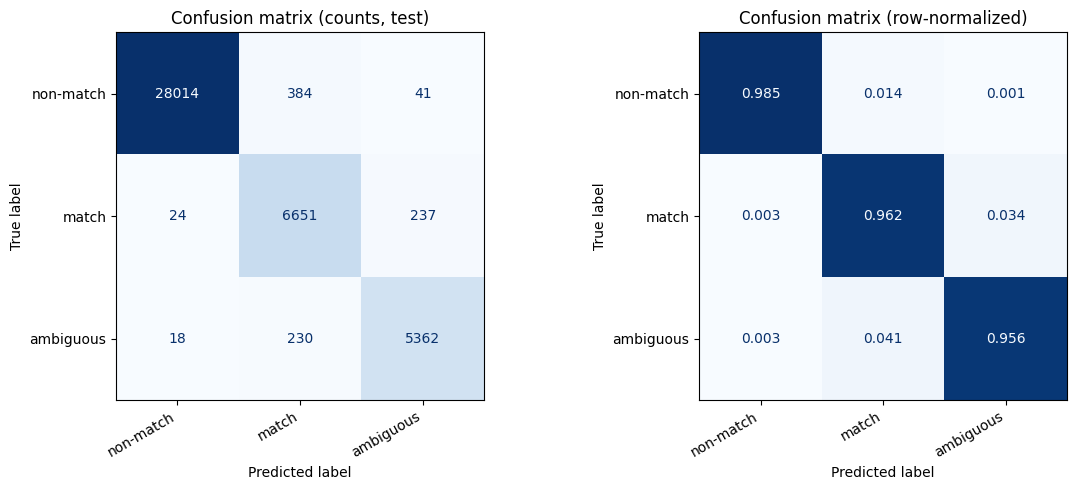

In [22]:
short = ['non-match', 'match', 'ambiguous']
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test, labels=[0, 1, 2]), display_labels=short).plot(
    ax=ax[0], colorbar=False, cmap='Blues')
ax[0].set_title('Confusion matrix (counts, test)')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test, labels=[0, 1, 2], normalize='true'), display_labels=short).plot(
    ax=ax[1], colorbar=False, cmap='Blues', values_format='.3f')
ax[1].set_title('Confusion matrix (row-normalized)')
for a in ax:
    a.set_xticklabels(short, rotation=30, ha='right')
plt.tight_layout(); plt.show()

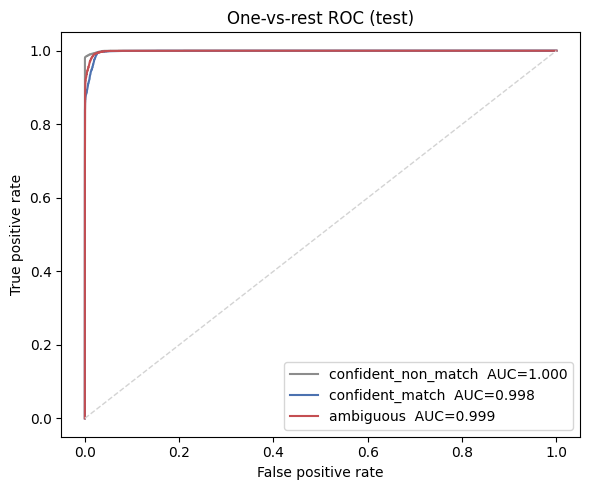

In [23]:
# One-vs-rest ROC curves, one per class.
Yb = label_binarize(y_test, classes=[0, 1, 2])
colors = ['#8C8C8C', '#4C72B0', '#C44E52']
plt.figure(figsize=(6, 5))
for k, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(Yb[:, k], proba_test[:, k])
    plt.plot(fpr, tpr, color=colors[k], label=f'{name}  AUC={roc_auc_score(Yb[:, k], proba_test[:, k]):.3f}')
plt.plot([0, 1], [0, 1], '--', color='lightgrey', linewidth=1)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('One-vs-rest ROC (test)'); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

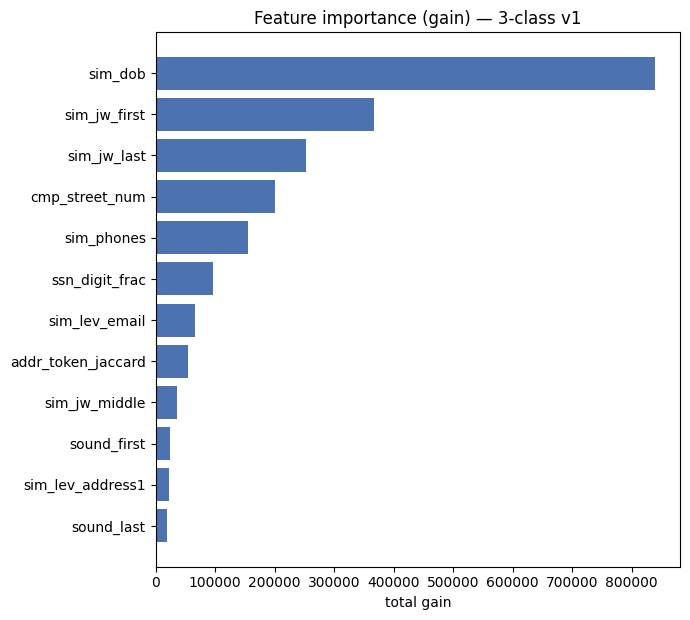

,feature,gain,split
10,sim_dob,839080.637531,903
3,sim_jw_first,366488.923435,4444
4,sim_jw_last,252970.621387,4180
2,cmp_street_num,201301.419327,405
11,sim_phones,155722.205966,3559
9,ssn_digit_frac,96858.357135,1369
6,sim_lev_email,66155.842417,1411
8,addr_token_jaccard,55081.611026,1941
5,sim_jw_middle,36702.968035,908
0,sound_first,23516.540681,496


In [24]:
imp = pd.DataFrame({'feature': model.feature_name_,
                    'gain': model.booster_.feature_importance(importance_type='gain'),
                    'split': model.booster_.feature_importance(importance_type='split')}).sort_values('gain', ascending=False)
fig, ax = plt.subplots(figsize=(7, 0.4 * len(imp) + 1.5))
ax.barh(imp['feature'][::-1], imp['gain'][::-1], color='#4C72B0')
ax.set(title='Feature importance (gain) — 3-class v1', xlabel='total gain')
plt.tight_layout(); plt.show()
imp

In [25]:
# Where does the model confuse ambiguous with the confident classes?
# For each true class, the mean predicted probability mass on each class.
leak = pd.DataFrame(proba_test, columns=CLASS_NAMES)
leak['true'] = [CLASS_NAMES[k] for k in y_test.values]
print('Mean predicted probability by true class:')
display(leak.groupby('true')[CLASS_NAMES].mean().round(3))

Mean predicted probability by true class:


,confident_non_match,confident_match,ambiguous
true,,,
ambiguous,0.005,0.048,0.947
confident_match,0.012,0.943,0.046
confident_non_match,0.986,0.010,0.003


## 9. Ablation — v1 categoricals vs the v3 feature set
Retrain the same multiclass config on only the eight `cmp_<field>` same/different/missing
categoricals (from `cmp_all`), same split, and compare. The gap is the lift from the similarity features.

In [26]:
v1_cols = [f'cmp_{n}' for n in SELECTED_FIELDS]
Xv1 = cmp_all[v1_cols]
Xv1_train, Xv1_val, Xv1_test = Xv1.iloc[idx_train], Xv1.iloc[idx_val], Xv1.iloc[idx_test]

m_v1 = lgb.LGBMClassifier(**params)
m_v1.fit(Xv1_train, y_train, eval_set=[(Xv1_val, y_val)], eval_metric='multi_logloss',
         categorical_feature=v1_cols,
         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)])
proba_v1 = m_v1.predict_proba(Xv1_test)

from sklearn.metrics import f1_score
comparison = pd.DataFrame({
    'model': ['v1 (8 categoricals)', '3-class v1 (similarity features)'],
    'n_features': [len(v1_cols), len(FEATURE_COLS)],
    'macro_ROC_AUC_ovr': [roc_auc_score(y_test, proba_v1, multi_class='ovr', average='macro'),
                          roc_auc_score(y_test, proba_test, multi_class='ovr', average='macro')],
    'macro_F1': [f1_score(y_test, proba_v1.argmax(1), average='macro'),
                 f1_score(y_test, pred_test, average='macro')],
}).round(4)
print('Held-out test comparison (same split, same config):')
comparison

Held-out test comparison (same split, same config):


,model,n_features,macro_ROC_AUC_ovr,macro_F1
0,v1 (8 categoricals),8,0.9923,0.9193
1,3-class v1 (similarity features),12,0.9989,0.9611


### Notes for the next iteration
- **Leakage-safe split** — PATID-grouped split for a stricter generalization estimate.
- **Decision policy** — argmax is the default; for a review-routing system consider an abstention
  rule (e.g. route to *ambiguous* whenever its probability exceeds a tuned threshold, even if not the
  argmax) to trade confident-class precision for ambiguous recall.
- **Hyperparameter search** — tune now that the feature set is stable.
- **Compare to the binary models** — this 3-class head vs the two-stage (match/non-match then
  ambiguity) pipeline on the same pairs.